## PA1: Segmentação de Instâncias com Arquiteturas da Aula
##### Disciplina: Aprendizado Profundo (Deep Learning) — FGV EMAp
##### Professor: Prof. Dario Oliveira | Monitor: Erick Brito
##### Equipe: Jaime Willian Carneiro da Silva e Luiz Eduardo Bravin

In [ ]:
!pip install -U ipython

In [ ]:
!git clone https://github.com/mistercapote/deep-learning-assignments.git

### 1. Importações

In [ ]:
import zipfile
          
zip_path = "/kaggle/input/competitions/data-science-bowl-2018/stage1_train.zip"
extract_path = "/kaggle/working/stage1_train"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

In [1]:
import sys
import os

# 1. Adicione o caminho correto do seu assignment ANTES de importar
sys.path.insert(0, '/kaggle/working/deep-learning-assignments/assignment-01')
sys.path.append(os.path.abspath('..')) 

%load_ext autoreload
%autoreload 2
    
# 2. Agora o Python conseguirá achar a pasta 'src'
from src import *

import torch
from torch.utils.data import DataLoader, random_split
import numpy as np
import cv2 as cv
from pathlib import Path
import time
from PIL import Image
import torchvision.transforms.functional as TF

### 2. Configurações

In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'xpu' if hasattr(torch, 'xpu') and torch.xpu.is_available() else 'cpu')
IOU_THRESHOLDS = np.arange(0.50, 1.00, 0.05)

PATH_TRAIN = Path('/kaggle/working/stage1_train')
BATCH_SIZE = 16
IMG_SIZE = 256
print(f'Device: {DEVICE}')

Device: cuda


### 3. Dataset

Escolhemos a opção A - DSB2018 / BBBC038v1 pelo forte interesse que temos em biologia computacional e bioimagem.

Download:  https://bbbc.broadinstitute.org/BBBC038

As classes `DSB2018BinaryDataset` e `DSB2018TernaryDataset` reescrevem as imagens em tensores, respectivamente, para a parte 1 e para a parte 2. As classes `SyntheticBinaryDataset` e `SyntheticTernaryDataset` fazem o mesmo, mas com  imagens de elipsses sintéticas criadas por `generate_synthetic_image`.

### 4. Modelo

Nosso modelo baseia-se na `ResNet34`. As classes que definem `UNetBinary` e `UNetTernary` apresentam encoder, decoder e forward idênticos, exceto pela saída que se adapta a cada parte.

### Parte 1

Primeiramente vamos usar os dados sintéticos:

In [ ]:
# Inicialização
model_s1 = UNetBinary().to(DEVICE)
full_ds_s1 = SyntheticBinaryDataset(num_samples=670)
train_ds_s1, val_ds_s2 = random_split(full_ds_s1, split(len(full_ds_s1)), generator=torch.Generator().manual_seed(SEED))
print(f'Train: {len(train_ds_s1)} amostras | Val: {len(val_ds_s2)} amostras')

train_loader_s1 = DataLoader(train_ds_s1, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_binary, pin_memory=True)
val_loader_s1 = DataLoader(val_ds_s2, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_binary, pin_memory=True)


# Treinamento
start_s1 = time.time()
history_s1 = train_model_binary(model_s1, train_loader_s1, val_loader_s1, "s1")
print(f"Tempo de treinamento: {(time.time() - start_s1)/60:.2f} minutos")
print(f"Melhor IoU (val): {max(history_s1['val_iou']):.4f}")
print(f"Dice corresp.: {history_s1['val_dice'][-1]:.4f}")
plot_training_curves_binary(history_s1)

# Avaliação
model_s1.load_state_dict(torch.load('../models/best_model_s1.pt', map_location=DEVICE, weights_only=True))

aps_s1, count_errors_s1, densities_s1, per_image_aps_s1, samples_s1 = evaluate_instances_binary(model_s1, val_loader_s1)

print("IoU : mAP | Média do mAP por imagem")
for i in range(len(IOU_THRESHOLDS)):
    print(f"{IOU_THRESHOLDS[i]:.2f} : {aps_s1[i]:.4f} | {per_image_aps_s1[i]:.4f}")
    
print(f'mAP (IoU 0.50:0.95): {np.mean(aps_s1):.4f}')
print(f"Média mAP: {np.mean(per_image_aps_s1):.4f}")
print(f"Média Erro Absoluto: {np.mean(count_errors_s1):.4f}")

plot_metrics(per_image_aps_s1, count_errors_s1, densities_s1)
plot_samples(samples_s1)

Agora vamos para os dados reais:

In [3]:
# Inicialização
model_binary = UNetBinary().to(DEVICE)
full_ds_binary = DSB2018BinaryDataset(PATH_TRAIN)
train_ds_binary, val_ds_binarytrain_ds_binary = random_split(full_ds_binary, split(len(full_ds_binary)), generator=torch.Generator().manual_seed(SEED))
print(f'Train: {len(train_ds_binary)} amostras | Val: {len(val_ds_binarytrain_ds_binary)} amostras')

train_loader_binary = DataLoader(train_ds_binary, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_binary, pin_memory=True)
val_loader_binary = DataLoader(val_ds_binarytrain_ds_binary, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_binary, pin_memory=True)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 201MB/s]


Train: 536 amostras | Val: 134 amostras


In [ ]:
# Treinamento
start_binary = time.time()
history_binary = train_model_binary(model_binary, train_loader_binary, val_loader_binary, "binary")
print(f"Tempo de treinamento: {(time.time() - start_binary)/60:.2f} minutos")
print(f"Melhor IoU (val): {max(history_binary['val_iou']):.4f}")
print(f"Dice corresp.: {history_binary['val_dice'][-1]:.4f}")
plot_training_curves_binary(history_binary)

In [ ]:
# Avaliação
model_binary.load_state_dict(torch.load('../models/best_model_binary.pt', map_location=DEVICE, weights_only=True))

aps_binary, count_errors_binary, densities_binary, per_image_aps_binary, samples_binary = evaluate_instances_binary(model_binary, val_loader_binary)

print("IoU : mAP | Média do mAP por imagem")
for i in range(len(IOU_THRESHOLDS)):
    print(f"{IOU_THRESHOLDS[i]:.2f} : {aps_binary[i]:.4f} | {per_image_aps_binary[i]:.4f}")
    
print(f'mAP (IoU 0.50:0.95): {np.mean(aps_binary):.4f}')
print(f"Média mAP: {np.mean(per_image_aps_binary):.4f}")
print(f"Média Erro Absoluto: {np.mean(count_errors_binary):.4f}")

plot_metrics(per_image_aps_binary, count_errors_binary, densities_binary)
plot_samples(samples_binary)

### Parte 2

Primeiramente vamos usar os dados sintéticos:

In [ ]:
# Inicialização
model_s2 = UNetTernary().to(DEVICE)
full_ds_s2 = SyntheticTernaryDataset(num_samples=670)
train_ds_s2, val_ds_s2train_ds_s2 = random_split(full_ds_s2, split(len(full_ds_s2)), generator=torch.Generator().manual_seed(SEED))
print(f'Train: {len(train_ds_s2)} amostras | Val: {len(val_ds_s2train_ds_s2)} amostras')

train_loader_s2 = DataLoader(train_ds_s2, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_ternary, pin_memory=True)
val_loader_s2 = DataLoader(val_ds_s2train_ds_s2, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_ternary, pin_memory=True)

# Treinamento
start_s2 = time.time()
history_s2 = train_model_ternary(model_s2, train_loader_s2, val_loader_s2, "s2")
print(f"Tempo de treinamento: {(time.time() - start_s2)/60:.2f} minutos")
plot_training_curves_ternary(history_s2)

# Avaliação
model_s2.load_state_dict(torch.load('../models/best_model_s2.pt', map_location=DEVICE, weights_only=True))
aps_s2, count_errors_s2, densities_s2, per_image_aps_s2, samples_s2 = evaluate_instances_ternary(model_s2, val_loader_s2)

print("IoU : mAP | Média do mAP por imagem")
for i in range(len(IOU_THRESHOLDS)):
    print(f"{IOU_THRESHOLDS[i]:.2f} : {aps_s2[i]:.4f} | {per_image_aps_s2[i]:.4f}")
    
print(f'mAP (IoU 0.50:0.95): {np.mean(aps_s2):.4f}')
print(f"Média mAP: {np.mean(per_image_aps_s2):.4f}")
print(f"Média Erro Absoluto: {np.mean(count_errors_s2):.4f}")

plot_metrics(per_image_aps_s2, count_errors_s2, densities_s2)
plot_samples(samples_s2)

Agora vamos para os dados reais:

In [5]:
# Inicialização
model_ternary = UNetTernary().to(DEVICE)
full_ds_ternary = DSB2018TernaryDataset(PATH_TRAIN, img_size=256)
train_ds_ternary, val_ds_ternary = random_split(full_ds_ternary, split(len(full_ds_ternary)), generator=torch.Generator().manual_seed(SEED))
print(f'Train: {len(train_ds_ternary)} amostras | Val: {len(val_ds_ternary)} amostras')

train_loader_ternary = DataLoader(train_ds_ternary, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_ternary, pin_memory=True)
val_loader_ternary = DataLoader(val_ds_ternary, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_ternary, pin_memory=True)

Train: 536 amostras | Val: 134 amostras


In [ ]:
# Treinamento
start_ternary = time.time()
history_ternary = train_model_ternary(model_ternary, train_loader_ternary, val_loader_ternary, "ternary")
print(f"Tempo de treinamento: {(time.time() - start_ternary)/60:.2f} minutos")
plot_training_curves_ternary(history_ternary)


In [ ]:
@torch.no_grad()
def evaluate_instances_ternary(
		model,
		loader,
		interior_thresh=0.55,
		fg_thresh=0.5,
		min_marker_size=5,
		k_samples=6,
):
	"""Avaliação idêntica à Parte 1: matching guloso por IoU decrescente."""
	model.eval()
	n_threshold = len(IOU_THRESHOLDS)
	tp_total = np.zeros(n_threshold)
	denom_total = np.zeros(n_threshold)

	count_errors = []
	densities = []
	per_image_aps = []
	samples = []

	for images, _, _, instance_masks_batch, _ in loader:
		images = images.to(DEVICE)
		logits_cls, dist_pred = model(images)
		probs_batch = F.softmax(logits_cls, dim=1).cpu().numpy()
		dists_batch = dist_pred.squeeze(1).cpu().numpy()

		for b in range(images.size(0)):
			pred_masks = decode_watershed(
					probs_batch[b],
					dists_batch[b],
					interior_thresh=interior_thresh,
					fg_thresh=fg_thresh,
					min_marker_size=min_marker_size,
			)
			gt_masks = instance_masks_batch[b]
			n_pred, n_gt = len(pred_masks), len(gt_masks)

			count_err = abs(n_pred - n_gt)
			count_errors.append(count_err)
			densities.append(n_gt)

			img_np = images[b].cpu().numpy().transpose(1, 2, 0)
			samples.append((count_err, img_np, gt_masks, pred_masks))

			if n_pred == 0 and n_gt == 0:
				per_image_aps.append(1.0)
				continue
			if n_pred == 0 or n_gt == 0:
				denom_total += n_pred + n_gt
				per_image_aps.append(0.0)
				continue

			# Matriz de IoU Vetorizada
			pred_flat = np.array(pred_masks, dtype=np.int32).reshape(n_pred, -1)
			gt_flat = np.array(gt_masks, dtype=np.int32).reshape(n_gt, -1)
			inter = np.dot(pred_flat, gt_flat.T)
			area_pred = pred_flat.sum(axis=1)[:, np.newaxis]
			area_gt = gt_flat.sum(axis=1)[np.newaxis, :]
			union = area_pred + area_gt - inter
			iou_matrix = inter / np.maximum(union, 1e-6)

			pairs = [
					(iou_matrix[i, j], i, j)
					for i in range(n_pred)
					for j in range(n_gt)
					if iou_matrix[i, j] > 0
			]
			pairs.sort(key=lambda x: -x[0])

			img_aps = np.zeros(n_threshold)
			for k, t in enumerate(IOU_THRESHOLDS):
				matched_pred, matched_gt = set(), set()
				tp = 0
				for iou, i, j in pairs:
					if iou < t:
						break
					if i not in matched_pred and j not in matched_gt:
						matched_pred.add(i)
						matched_gt.add(j)
						tp += 1
				fp = n_pred - tp
				fn = n_gt - tp
				denom = tp + fp + fn
				img_aps[k] = tp / denom if denom > 0 else 1.0

				tp_total[k] += tp
				denom_total[k] += denom

			per_image_aps.append(float(img_aps.mean()))

	aps = np.where(denom_total > 0, tp_total / denom_total, 1.0)
	samples.sort(key=lambda s: -s[0])
	return aps, count_errors, densities, per_image_aps, samples[:k_samples]



In [ ]:
# Avaliação
model_ternary.load_state_dict(torch.load('../models/best_model_ternary.pt', map_location=DEVICE, weights_only=True))

aps_ternary, count_errors_ternary, densities_ternary, per_image_aps_ternary, samples_ternary = evaluate_instances_ternary(model_ternary, val_loader_ternary)

print("IoU : mAP | Média do mAP por imagem")
for i in range(len(IOU_THRESHOLDS)):
    print(f"{IOU_THRESHOLDS[i]:.2f} : {aps_ternary[i]:.4f} | {per_image_aps_ternary[i]:.4f}")
    
print(f'mAP (IoU 0.50:0.95): {np.mean(aps_ternary):.4f}')
print(f"Média mAP: {np.mean(per_image_aps_ternary):.4f}")
print(f"Média Erro Absoluto: {np.mean(count_errors_ternary):.4f}")

plot_metrics(per_image_aps_ternary, count_errors_ternary, densities_ternary)
plot_samples(samples_ternary)

Quanto maior a quantidade de elipses, maior facilidade de ter intersecção entre elas. Com isso, o modelo interpreta como se fosse apenas um objeto, logo diminuindo o mAP e aumentando o erro absoluto de contagem. 

### Parte 3

In [ ]:
ablation(train_ds_ternary, val_ds_ternary)


In [ ]:
ablation(traiin)

### Parte 4

In [ ]:
mosaic_img, mosaic_inst = create_mosaic_real(val_ds_ternary, indices=[0, 1, 2, 3])

print(f"📦 Formato da imagem do mosaico: {mosaic_img.shape}")
print(f"🏷️ Formato da máscara de instâncias do mosaico: {mosaic_inst.shape}")
print(f"🔢 Total de instâncias únicas no mosaico: {len(np.unique(mosaic_inst)) - 1}")


In [ ]:
tiles, coords = mosaic_tile_inference_demo(mosaic_img, tile_size=128, overlap=32)

print(f"🧩 Número total de tiles gerados: {len(tiles)}")
print(f"📍 Coordenadas (y_start, y_end, x_start, x_end) do primeiro tile: {coords[0]}")
print(f"📦 Formato de cada tile: {tiles[0].shape}")

In [ ]:
# real_model = UNetBinary()
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# start = time.time()
# train_model(real_model, real_train_loader, device, part=1, num_epochs=5)
# print(f"Training time: {(time.time() - start) / 60:.2f} minutes")
# real_mAP, real_count_errors, real_densities, synthetic_samples = evaluate(real_model, real_val_loader, device, part =1)
# plot_metrics(real_mAP, real_count_errors, real_densities)
# plot_samples(synthetic_samples, part=1)

model_ternary = UNetTernary().to(DEVICE)


model_ternary.load_state_dict(torch.load('../models/best_model_ternary.pt', map_location=DEVICE, weights_only=True))

pred_naive = mosaic_inference_naive_watershed(
    model=model_ternary,
    mosaic_img=mosaic_img,
    tile_size=128,
    stride=96,
    device=DEVICE,
    interior_thresh=0.4,
    fg_thresh=0.5,
    min_marker_size=5
)
print("Número de instâncias:", len(pred_naive))

plt.figure(figsize=(12, 6))

plt.imshow(mosaic_img.transpose(1, 2, 0))

for mask in pred_naive:
    plt.contour(mask, levels=[0.5], linewidths=1)

plt.axis("off")
plt.title("Predições Watershed no mosaico — sem fusão")
plt.show()

In [ ]:
pred_fusion_labels = mosaic_inference_watershed_with_fusion(
    model=    model_ternary,
    large_image=mosaic_img,
    tile_size=128,
    overlap=32,
    device=DEVICE,
    interior_thresh=0.4,
    fg_thresh=0.5,
    min_marker_size=5,
    fusion_iou_thresh=0.3,
)

pred_fusion = label_mask_to_instances(
    pred_fusion_labels
)

In [ ]:
print("Número de instâncias após fusão:",
      len(np.unique(pred_fusion_labels)) - 1)

In [ ]:
plt.figure(figsize=(12, 6))

plt.imshow(mosaic_img.transpose(1, 2, 0))

for instance_id in np.unique(pred_fusion):

    if instance_id == 0:
        continue

    mask = pred_fusion == instance_id

    plt.contour(
        mask,
        levels=[0.5],
        linewidths=1
    )

plt.axis("off")
plt.title("Predições Watershed no mosaico — com fusão")
plt.show()

In [ ]:
for thresh in [0.2, 0.3, 0.5, 0.7]:
    
    pred = mosaic_inference_watershed_with_fusion(
        model=model_ternary,
        large_image=mosaic_img,
        tile_size=128,
        overlap=32,
        device=DEVICE,
        interior_thresh=0.4,
        fg_thresh=0.5,
        min_marker_size=5,
        fusion_iou_thresh=thresh,
    )

    n_instances = len(np.unique(pred)) - 1

    print(
        f"IoU = {thresh:.1f} → "
        f"{n_instances} instâncias"
    )

In [ ]:
gt_masks = label_mask_to_instances(mosaic_inst)

print("Número de instâncias GT:", len(gt_masks))
print("Shape de cada máscara:", gt_masks[0].shape)

In [ ]:
aps_naive, map_naive, count_naive = evaluate_mosaic_instances(
    pred_naive,
    gt_masks
)

aps_fusion, map_fusion, count_fusion = evaluate_mosaic_instances(
    pred_fusion,
    gt_masks
)

In [ ]:
print("======================================")
print("NAIVE")
print("======================================")
print(f"Instâncias previstas: {len(pred_naive)}")
print(f"Instâncias GT:        {len(gt_masks)}")
print(f"Erro de contagem:     {count_naive}")
print(f"mAP:                  {map_naive:.4f}")

print()

print("======================================")
print("FUSION")
print("======================================")
print(f"Instâncias previstas: {len(pred_fusion)}")
print(f"Instâncias GT:        {len(gt_masks)}")
print(f"Erro de contagem:     {count_fusion}")
print(f"mAP:                  {map_fusion:.4f}")

A inferência naive produziu 246 instâncias para 168 instâncias reais, resultando em erro absoluto de contagem de 78 objetos e mAP de 0,2819. Após a aplicação da fusão baseada em IoU nas regiões de sobreposição dos tiles, o número de instâncias previstas foi reduzido para 139, diminuindo o erro de contagem para 29 e elevando o mAP para 0,4104. Os resultados indicam que uma parcela significativa das detecções adicionais da abordagem naive correspondia a duplicações de instâncias entre tiles. Entretanto, a fusão também pode eliminar ou unir incorretamente algumas instâncias, como indicado pela subcontagem final de 29 objetos.

### Parte 5

In [ ]:
path_train = Path('/kaggle/working/stage1_train')
df = pd.read_csv('/kaggle/working/deep-learning-assignments/assignment-01/models/metrics_per_image.csv')

df_sorted_error = df.sort_values(by = 'count_error', ascending=False)
df_sorted_map = df.sort_values(by = 'mAP_image')
df_sorted_error.head(5)

In [ ]:
df_sorted_map

In [ ]:

# train_loader_binary = DataLoader(train_ds_binary, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_binary, pin_memory=True)
# val_loader_binary = DataLoader(val_ds_binarytrain_ds_binary, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_binary, pin_memory=True)

In [ ]:
# Analisar as falhas

top_5_ids = df_sorted_error['id'].head(5).to_list()
top_5_ids

In [ ]:
for img_id in top_5_ids:
    img_path = path_train / img_id / 'images' / f'{img_id}.png'
    mask_dir = path_train / img_id / 'masks'

    image = np.array(Image.open(img_path).convert('RGB'))
    plt.imshow(image)
    plt.show()

In [ ]:
model_baseline = UNetTernary().to(DEVICE)

rf_baseline, stride_baseline = resnet34_encoder_rf(model_baseline)

model_stride8 = UNetTernary()


for i, block in enumerate(model_stride8.enc4):
    if i == 0:
        block.conv1.stride = (1, 1)

        if block.downsample is not None:
            block.downsample[0].stride = (1, 1)


rf_stride8, stride_stride8 = resnet34_encoder_rf(model_stride8)


In [ ]:
model_dilated = UNetTernaryDilated()

rf_dilated, stride_dilated = resnet34_encoder_rf(model_dilated)



In [ ]:
print(
    f"Encoder padrão             : "
    f"RF = {rf_baseline} px | "
    f"output stride = {stride_baseline}"
)

print(
    f"Encoder stride 8 sem atrous: "
    f"RF = {rf_stride8} px | "
    f"output stride = {stride_stride8}"
)

print(
    f"Encoder stride 8 com atrous: "
    f"RF = {rf_dilated} px | "
    f"output stride = {stride_dilated}"
)

print(
    f"\nEfeito da dilatação no mesmo output stride: "
    f"+{rf_dilated - rf_stride8} px de RF"
)

#### Distribuição de tamanhos dos objetos do dataset vs. campo receptivo

Percorremos as máscaras individuais (`.../masks/*.png`) de todo o `stage1_train`, medimos o diâmetro equivalente de cada núcleo e comparamos essa distribuição com o RF teórico calculado acima.

In [ ]:
diameters = object_diameters(path_train)

print(
    f"{len(diameters)} instâncias | "
    f"diâmetro médio = {diameters.mean():.1f} px | "
    f"mediana = {np.median(diameters):.1f} px | "
    f"p95 = {np.percentile(diameters, 95):.1f} px | "
    f"máximo = {diameters.max():.1f} px"
)

# Comparação entre o tamanho dos objetos e o output stride
print(
    f"\nObjetos com diâmetro <= {stride_baseline/2:.0f} px: "
    f"{(diameters <= stride_baseline/2).mean()*100:.2f}%"
)

print(
    f"Objetos com diâmetro <= {stride_baseline:.0f} px: "
    f"{(diameters <= stride_baseline).mean()*100:.2f}%"
)

print(
    f"Objetos com diâmetro > {stride_baseline:.0f} px: "
    f"{(diameters > stride_baseline).mean()*100:.2f}%"
)

plt.figure(figsize=(8, 4))

plt.hist(
    diameters,
    bins=40,
    alpha=0.8
)

plt.axvline(
    rf_baseline,
    linestyle="--",
    label=f"RF baseline ({rf_baseline}px)"
)

plt.axvline(
    rf_dilated,
    linestyle="--",
    label=f"RF dilatado ({rf_dilated}px)"
)

plt.xlabel("Diâmetro equivalente do objeto (px)")
plt.ylabel("Número de instâncias")

plt.title(
    "Distribuição do tamanho dos núcleos "
    "vs. campo receptivo do encoder"
)

plt.legend()
plt.show()


frac_maior_que_rf = (
    diameters > rf_baseline
).mean() * 100

frac_maior_que_rf_dilated = (
    diameters > rf_dilated
).mean() * 100

print(
    f"{frac_maior_que_rf:.2f}% das instâncias "
    f"têm diâmetro maior que o RF do encoder padrão."
)

print(
    f"{frac_maior_que_rf_dilated:.2f}% das instâncias "
    f"têm diâmetro maior que o RF do encoder dilatado."
)


In [ ]:
CHECKPOINT_PATH = "/kaggle/working/deep-learning-assignments/assignment-01/models/best_model_ternary.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"

model_final = UNetTernary().to(device)

model_final.load_state_dict(
    torch.load(
        CHECKPOINT_PATH,
        map_location=device,
        weights_only=True
    )
)

model_final.eval()

# Convenção dos canais
BG, INTERIOR, BOUNDARY = 0, 1, 2

In [ ]:
def load_instance_gt(mask_dir):
    """Empilha as máscaras individuais do DSB2018 em um único array rotulado (H, W)."""
    mask_dir = Path(mask_dir)
    gt = None

    for i, p in enumerate(sorted(mask_dir.glob("*.png")), start=1):
        m = np.array(Image.open(p)) > 0

        if gt is None:
            gt = np.zeros(m.shape, dtype=np.int32)

        gt[m] = i

    return gt


IMG_SIZE = 256  # mesmo tamanho usado no treinamento

diagnósticos = []

for img_id in top_5_ids:

    img_path = path_train / img_id / "images" / f"{img_id}.png"
    mask_dir = path_train / img_id / "masks"

    # Imagem original
    image = np.array(
        Image.open(img_path).convert("RGB")
    )

    # Ground truth de instâncias
    gt_instances = load_instance_gt(mask_dir)

    # Preparação da entrada
    inp = (
        TF.to_tensor(
            Image.fromarray(image).resize(
                (IMG_SIZE, IMG_SIZE)
            )
        )
        .unsqueeze(0)
        .to(device)
    )

    # Predição
    with torch.no_grad():
        logits_cls, dist_pred = model_final(inp)

    # Converte logits em probabilidades
    probs = F.softmax(logits_cls[0], dim=0)

    # Probabilidade de fronteira para visualização
    boundary_prob = probs[BOUNDARY].cpu().numpy()

    # Probabilidades esperadas pelo decode_watershed
    class_probs = [
        probs[BG].cpu().numpy(),
        probs[INTERIOR].cpu().numpy(),
        probs[BOUNDARY].cpu().numpy(),
    ]

    # Mapa de distância previsto
    dist_map = dist_pred[0, 0].cpu().numpy()

    # Watershed
    pred_masks = decode_watershed(
    class_probs,
    dist_map=dist_map,
    interior_thresh=0.55,
    fg_thresh=0.5,
    min_marker_size=5
)
    # Converte as máscaras individuais em um mapa de instâncias
    pred_instances = np.zeros(
        (IMG_SIZE, IMG_SIZE),
        dtype=np.int32
    )

    for instance_id, mask in enumerate(pred_masks, start=1):
        pred_instances[mask > 0] = instance_id

    # Redimensiona GT mantendo IDs das instâncias
    gt_resized = np.array(
        Image.fromarray(
            gt_instances.astype(np.int32)
        ).resize(
            (IMG_SIZE, IMG_SIZE),
            resample=Image.Resampling.NEAREST
        )
    )

    # Diâmetro dos objetos
    diam = [
        r.equivalent_diameter_area
        for r in regionprops(gt_resized)
    ]

    max_diam = max(diam) if diam else 0

    # Métricas da imagem
    linha = df[df["id"] == img_id].iloc[0]

In [ ]:
diagnósticos = []


for img_id in top_5_ids:

    # ============================================================
    # 1. Caminhos
    # ============================================================

    img_path = (
        path_train
        / img_id
        / "images"
        / f"{img_id}.png"
    )

    mask_dir = (
        path_train
        / img_id
        / "masks"
    )


    # ============================================================
    # 2. Imagem original
    # ============================================================

    image = np.array(
        Image.open(img_path).convert("RGB")
    )


    # ============================================================
    # 3. Ground truth de instâncias
    # ============================================================

    gt_instances = load_instance_gt(mask_dir)


    # ============================================================
    # 4. Redimensiona o GT para 256 x 256
    # ============================================================

    gt_resized = np.array(
        Image.fromarray(
            gt_instances.astype(np.int32)
        ).resize(
            (IMG_SIZE, IMG_SIZE),
            resample=Image.Resampling.NEAREST
        )
    )


    # ============================================================
    # 5. Gera o rótulo ternário
    # ============================================================

    ternary_gt = instance_gt_to_ternary(
        gt_resized,
        boundary_width=2
    )


    # ============================================================
    # 6. Prepara a imagem para a rede
    # ============================================================

    inp = (
        TF.to_tensor(
            Image.fromarray(image).resize(
                (IMG_SIZE, IMG_SIZE)
            )
        )
        .unsqueeze(0)
        .to(device)
    )


    # ============================================================
    # 7. Predição do modelo
    # ============================================================

    model_final.eval()

    with torch.no_grad():
        logits_cls, dist_pred = model_final(inp)


    # ============================================================
    # 8. Probabilidades das três classes
    # ============================================================

    probs = F.softmax(
        logits_cls[0],
        dim=0
    )


    # ============================================================
    # 9. Probabilidade da classe fronteira
    # ============================================================

    boundary_prob = (
        probs[BOUNDARY]
        .cpu()
        .numpy()
    )


    # ============================================================
    # 10. Predição ternária
    # ============================================================

    pred_ternary = torch.argmax(
        logits_cls[0],
        dim=0
    ).cpu().numpy()


    # ============================================================
    # 11. Número de instâncias do ground truth
    # ============================================================

    n_gt = len(
        regionprops(gt_resized)
    )


    # ============================================================
    # 12. Métricas da imagem
    # ============================================================

    linha = df[
        df["id"] == img_id
    ].iloc[0]


    # ============================================================
    # 13. Galeria
    # ============================================================

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(16, 4)
    )


    # Imagem
    axes[0].imshow(image)
    axes[0].set_title("Imagem")
    axes[0].axis("off")


    # Ground truth de instâncias
    axes[1].imshow(
        gt_instances,
        cmap="nipy_spectral"
    )

    axes[1].set_title(
        f"Ground truth ({n_gt} instâncias)"
    )

    axes[1].axis("off")


    # Ground truth ternário
    axes[2].imshow(
        ternary_gt,
        cmap="viridis",
        vmin=0,
        vmax=2
    )

    axes[2].set_title(
        "Ground truth ternário"
    )

    axes[2].axis("off")


    # Predição ternária
    axes[3].imshow(
        pred_ternary,
        cmap="viridis",
        vmin=0,
        vmax=2
    )

    axes[3].set_title(
        "Predição ternária"
    )

    axes[3].axis("off")


    # Título geral
    fig.suptitle(
        f"{img_id} | "
        f"count_error={linha['count_error']} | "
        f"mAP={linha['mAP_image']:.3f}"
    )


    plt.tight_layout()
    plt.show()


    # ============================================================
    # 14. Diagnóstico
    # ============================================================

    diam = [
        r.equivalent_diameter_area
        for r in regionprops(gt_resized)
    ]

    max_diam = max(diam) if diam else 0


    diagnostico = (
        f"[{img_id}] O maior objeto tem aproximadamente "
        f"{max_diam:.1f} px de diâmetro. "
        f"O rótulo ternário possui {n_gt} instâncias no "
        f"ground truth. A fronteira é definida pela sobreposição "
        f"das dilatações de instâncias vizinhas, evitando que "
        f"objetos isolados recebam uma fronteira artificial "
        f"contra o fundo."
    )


    print(diagnostico)

    diagnósticos.append(
        diagnostico)

#### Gerar rótulo ternário (fundo / interior / fronteira) a partir das máscaras individuais

Usado no treino de `UNetTernary`/`UNetTernaryDilated` com perda CE balanceada. A fronteira é obtida por dilatação de cada instância individual e depois interseção entre instâncias vizinhas — assim ela existe só onde dois objetos se tocam ou ficam próximos, e não na borda externa de um objeto isolado contra o fundo.

In [10]:


model_baseline = UNetTernary().to(DEVICE)

checkpoint = torch.load(
    "/kaggle/working/deep-learning-assignments/assignment-01/models/best_model_ternary.pt", 
    map_location=DEVICE
)

model_baseline.load_state_dict(checkpoint)

aps, count_errors, densities, per_image_aps, samples = evaluate_instances_ternary(
    model_baseline,
    val_loader_ternary,
    interior_thresh=0.55,
    fg_thresh=0.5,
    min_marker_size=5
)

mAP_before = np.mean(aps)
count_error_before = np.mean(count_errors)

print("Baseline")
print(f"mAP          : {mAP_before:.4f}")
print(f"count_error  : {count_error_before:.2f}")

Baseline
mAP          : 0.3492
count_error  : 16.63


In [11]:
model_correction = UNetTernaryDilated().to(DEVICE)

train_model_ternary(
    model_correction,
    train_loader_ternary,
    val_loader_ternary,
    epochs=10,
    lr=1e-3
)

aps_after, count_errors_after, densities_after, per_image_aps_after, samples_after = evaluate_instances_ternary(
    model_correction,
    val_loader_ternary,
    interior_thresh=0.55,
    fg_thresh=0.5,
    min_marker_size=5
)

mAP_after = np.mean(aps_after)
count_error_after = np.mean(count_errors_after)

print("\nBefore / After")

print(f"{'':20s}{'mAP':>10s}{'count_error':>15s}")
print(f"{'Baseline':20s}{mAP_before:10.4f}{count_error_before:15.2f}")
print(f"{'Dilated':20s}{mAP_after:10.4f}{count_error_after:15.2f}")

Epoch 01/10 | Train Loss: 0.6189 | Val Loss: 0.1969 (Cls: 0.1607, Dist: 0.0362)
Epoch 02/10 | Train Loss: 0.2763 | Val Loss: 0.1547 (Cls: 0.1214, Dist: 0.0333)
Epoch 03/10 | Train Loss: 0.2322 | Val Loss: 0.1145 (Cls: 0.0839, Dist: 0.0305)
Epoch 04/10 | Train Loss: 0.2076 | Val Loss: 0.1083 (Cls: 0.0784, Dist: 0.0299)
Epoch 05/10 | Train Loss: 0.1862 | Val Loss: 0.1119 (Cls: 0.0819, Dist: 0.0300)
Epoch 06/10 | Train Loss: 0.1773 | Val Loss: 0.1013 (Cls: 0.0719, Dist: 0.0293)
Epoch 07/10 | Train Loss: 0.1734 | Val Loss: 0.1017 (Cls: 0.0730, Dist: 0.0287)
Epoch 08/10 | Train Loss: 0.1834 | Val Loss: 0.1332 (Cls: 0.1036, Dist: 0.0296)
Epoch 09/10 | Train Loss: 0.1763 | Val Loss: 0.1120 (Cls: 0.0853, Dist: 0.0268)
Epoch 10/10 | Train Loss: 0.1631 | Val Loss: 0.0948 (Cls: 0.0684, Dist: 0.0264)

Before / After
                           mAP    count_error
Baseline                0.3492          16.63
Dilated                 0.3459          16.56


RF do encoder padrão já satura completamente o tamanho de qualquer instância do dataset (547 px >> 32,3 px do p95), então a dilatação não traz ganho de contexto real — só custo extra e artefatos de gridding que prejudicam a segmentação fina de núcleos pequenos. Some a isso uma comparação metodologicamente não pareada (sem seed fixa, sem seleção do melhor checkpoint para o modelo dilatado), e o resultado — leve piora no mAP com leve melhora no erro de contagem — é plausível sem indicar que a arquitetura dilatada seja "pior" em geral; ela só não era a alteração certa para este gargalo específico.

### Parte 6 — Teste de estresse: corrupções

Avaliaremos a robustez do modelo final sob três tipos de corrupção da imagem de entrada:

- blur;
- ruído Gaussiano;
- alteração de brilho e contraste.

Cada corrupção será aplicada em três intensidades crescentes. O desempenho será medido pelo mAP de instâncias e pelo erro absoluto de contagem.

In [12]:
# Modelo final usado no teste de estresse
stress_model = model_correction
stress_loader = val_loader_ternary

In [15]:
# mAP nas imagens originais, sem corrupção
baseline_aps, _, _, _, _ = evaluate_instances_ternary(
    stress_model,
    stress_loader,
    interior_thresh=0.55,
    fg_thresh=0.5,
    min_marker_size=5
)

baseline_map = np.mean(baseline_aps)

print(f"mAP sem corrupção: {baseline_map:.4f}")

mAP sem corrupção: 0.3459


In [16]:


corruptions = [
    "blur",
    "noise",
    "brightness_contrast"
]

results = []

for corruption in corruptions:

    for intensity in [1, 2, 3]:

        mAP, count_error = evaluate_corrupted(
            stress_model,
            stress_loader,
            DEVICE,
            corruption,
            intensity
        )

        results.append({
            "corruption": corruption,
            "intensity": intensity,
            "mAP": mAP,
            "count_error": count_error
        })

        print(
            f"{corruption} | "
            f"intensidade {intensity} | "
            f"mAP = {mAP:.4f} | "
            f"erro contagem = {count_error:.4f}"
        )

blur | intensidade 1 | mAP = 0.3122 | erro contagem = 15.8284
blur | intensidade 2 | mAP = 0.2253 | erro contagem = 15.2612
blur | intensidade 3 | mAP = 0.1461 | erro contagem = 15.7239
noise | intensidade 1 | mAP = 0.2790 | erro contagem = 20.3806
noise | intensidade 2 | mAP = 0.0826 | erro contagem = 40.7910
noise | intensidade 3 | mAP = 0.0159 | erro contagem = 46.8209
brightness_contrast | intensidade 1 | mAP = 0.3457 | erro contagem = 17.8209
brightness_contrast | intensidade 2 | mAP = 0.3348 | erro contagem = 19.0597
brightness_contrast | intensidade 3 | mAP = 0.3192 | erro contagem = 20.1045


In [17]:
results_df = pd.DataFrame(results)

results_df

,corruption,intensity,mAP,count_error
0,blur,1,0.312239,15.828358
1,blur,2,0.225260,15.261194
2,blur,3,0.146147,15.723881
3,noise,1,0.278954,20.380597
4,noise,2,0.082600,40.791045
5,noise,3,0.015937,46.820896
6,brightness_contrast,1,0.345743,17.820896
7,brightness_contrast,2,0.334754,19.059701
8,brightness_contrast,3,0.319235,20.104478


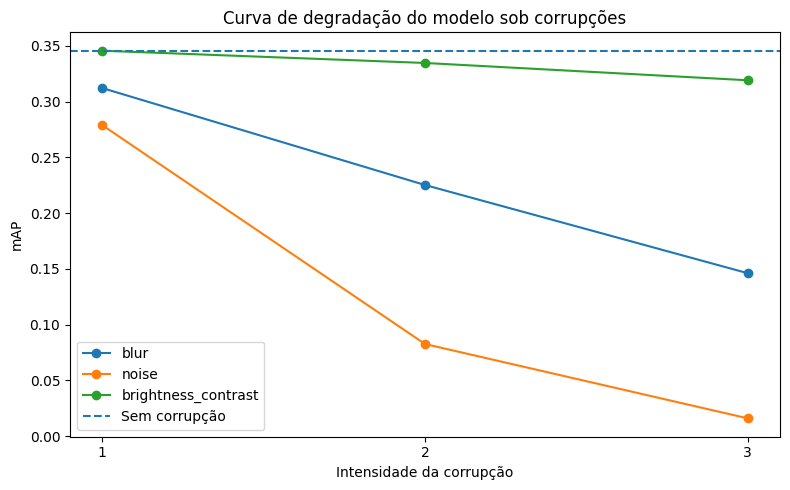

In [18]:
plt.figure(figsize=(8, 5))

for corruption in corruptions:
    subset = results_df[
        results_df["corruption"] == corruption
    ]

    plt.plot(
        subset["intensity"],
        subset["mAP"],
        marker="o",
        label=corruption
    )

# Baseline sem corrupção
plt.axhline(
    baseline_map,
    linestyle="--",
    label="Sem corrupção"
)

plt.xlabel("Intensidade da corrupção")
plt.ylabel("mAP")
plt.title("Curva de degradação do modelo sob corrupções")
plt.xticks([1, 2, 3])
plt.legend()
plt.tight_layout()
plt.show()

O teste de estresse mostrou que o modelo apresenta maior sensibilidade ao ruído Gaussiano, cuja intensidade máxima reduziu o mAP de aproximadamente 0,346 para 0,016. O desfoque também provocou uma degradação progressiva, com mAP reduzido para aproximadamente 0,146 na maior intensidade. Em contraste, o modelo apresentou maior robustez às alterações de brilho e contraste, mantendo mAP próximo de 0,32 mesmo na intensidade máxima.